In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
df = pd.read_csv(r"C:\Users\Charan\Desktop\JavaScript\Internship\TAKEITSMART\heart.csv")

print(df.head())
print(df.shape)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
(1025, 14)


In [7]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [8]:
df.fillna(df.mean(), inplace=True)

In [9]:
print(df.duplicated().sum())

723


In [10]:
df.drop_duplicates(inplace=True)

In [11]:
print(df.skew())

age        -0.203743
sex        -0.786120
cp          0.493022
trestbps    0.716541
chol        1.147332
fbs         1.981201
restecg     0.169467
thalach    -0.532671
exang       0.737281
oldpeak     1.266173
slope      -0.503247
ca          1.295738
thal       -0.481232
target     -0.173691
dtype: float64


In [12]:
df['chol'] = np.log1p(df['chol'])

In [13]:
df['oldpeak'] = np.log1p(df['oldpeak'])
df['ca'] = np.log1p(df['ca'])

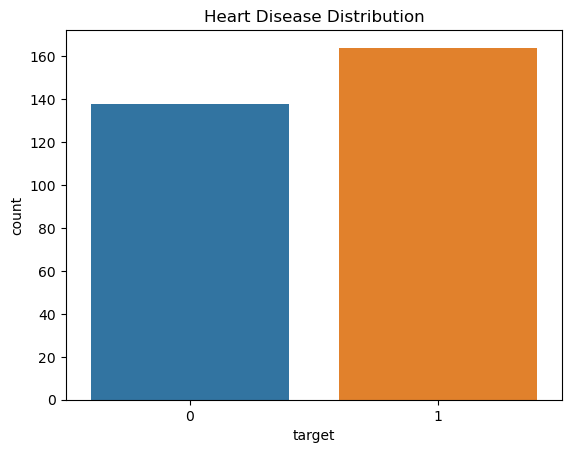

In [16]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

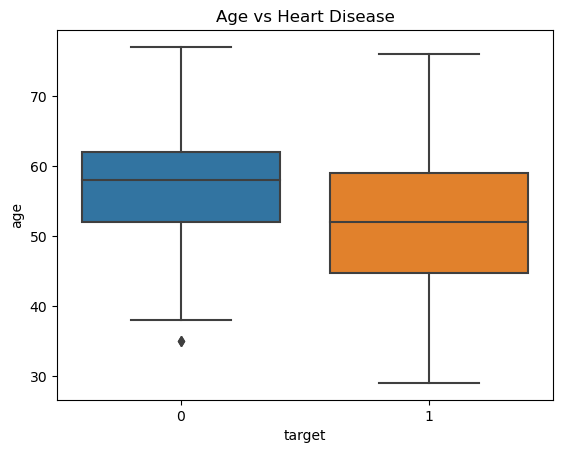

In [17]:
sns.boxplot(x='target', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

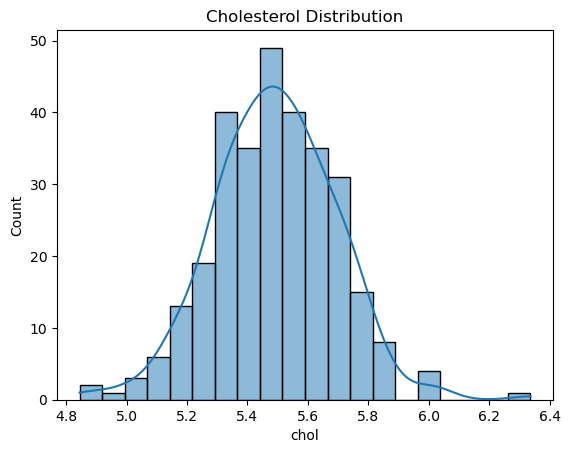

In [18]:
sns.histplot(df['chol'], bins=20, kde=True)
plt.title("Cholesterol Distribution")
plt.show()

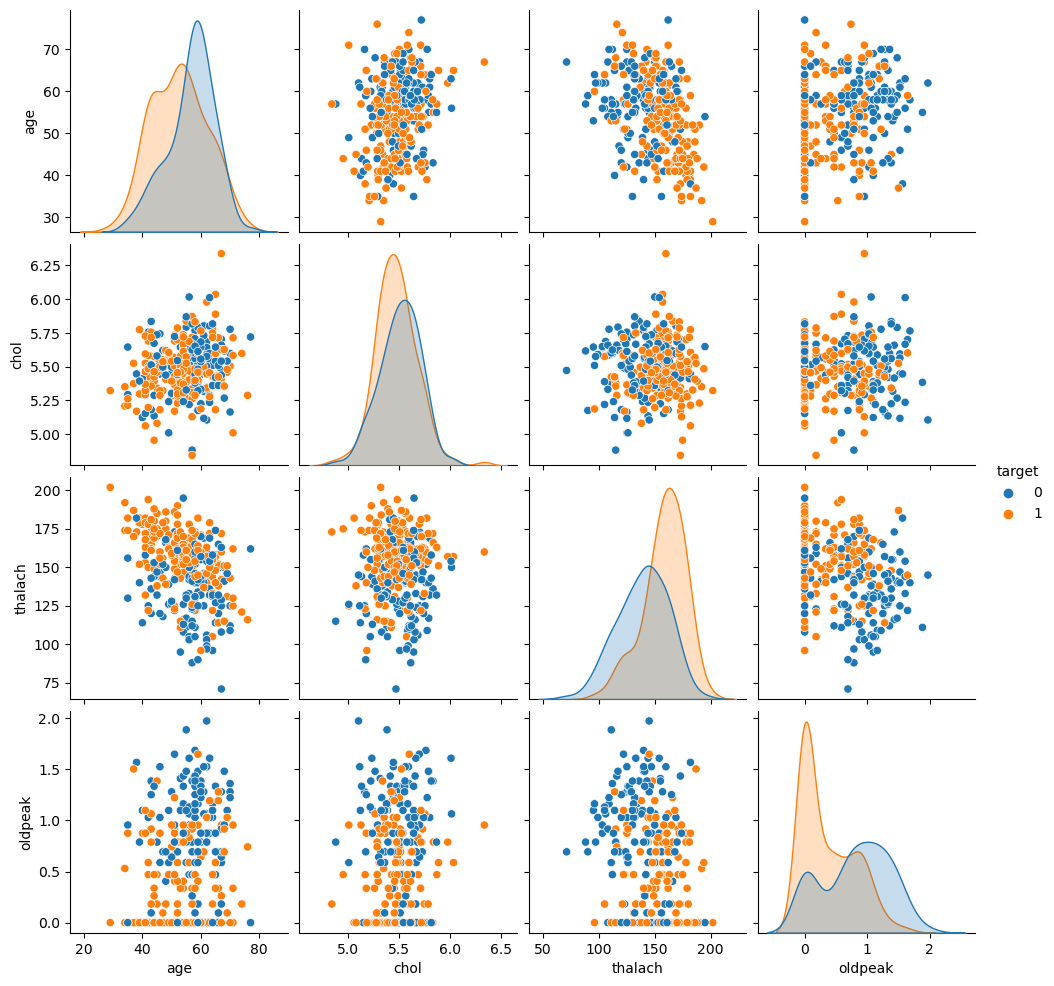

In [19]:
sns.pairplot(df[['age','chol','thalach','oldpeak','target']], hue='target')
plt.show()

In [20]:
X = df.drop('target', axis=1)
y = df['target']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [24]:
y_pred = model.predict(X_test)

In [25]:
y_pred_class = (y_pred >= 0.5).astype(int)

In [26]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_class))

Accuracy: 0.7868852459016393
